# To run:
### Ordner (Name: mouseDataExpBCompl), der alle Participant - CSV Dateien beinhaltet auf selber Ebene wie dieses Notebook.
### und df_for_trialexclusion.csv auf selber Ebene

---------------------------------------------------------------------------------------------------------------------------------

In [ ]:
import pandas as pd
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
folder_path = 'mouseDataExpBCompl'


exclude_ids = ['9468', '9902',  # Error Outlier
               '2786', '6382', '6892',  # Bugs
               '5883',  # Incomplete Data
               '2878', '4420', '2523', '9025']  # Touchpad User

csv_files = glob.glob(os.path.join(folder_path, '*.csv'))
filtered_files = [
    file for file in csv_files
    if not any(ex_id in os.path.basename(file) for ex_id in exclude_ids)
]

dataframes = [pd.read_csv(file) for file in filtered_files]
len(dataframes)


53

### Alle die mit 1 in df_for_trialexclusion markiert sind rausschmeißen

In [ ]:
exclusion_df = pd.read_csv('df_for_trialexclusion.csv') 
excluded = exclusion_df[exclusion_df['trial_excl'] == 1][['id', 'round', 'trial']]
dataframes_without_excluded = []

for df in dataframes:
    if all(col in df.columns for col in ['id', 'round', 'trial']):
        merged = df.merge(excluded, on=['id', 'round', 'trial'], how='left', indicator=True)
        df_cleaned = merged[merged['_merge'] == 'left_only'].drop(columns=['_merge'])
        dataframes_without_excluded.append(df_cleaned)
    else:
        dataframes_without_excluded.append(df) 

In [6]:
dataframes[0]

,id,round,trial,version,timestamp,frame,relative_time,mouse_x,mouse_y,mouse_dx,mouse_dy,phase,event
0,1085,0,1,lld,14:12:59.280,3701,0.020,0.068,-0.100,0.0,0.0,waitingForTarget,middleTargetClick
1,1085,0,1,lld,14:12:59.343,3702,0.083,0.068,-0.100,0.0,0.0,waitingForTarget,noEvent
2,1085,0,1,lld,14:12:59.352,3703,0.093,0.068,-0.100,0.0,0.0,waitingForTarget,noEvent
3,1085,0,1,lld,14:12:59.357,3704,0.101,0.068,-0.100,0.0,0.0,waitingForTarget,noEvent
4,1085,0,1,lld,14:12:59.373,3705,0.117,0.068,-0.100,0.0,0.0,waitingForTarget,noEvent
...,...,...,...,...,...,...,...,...,...,...,...,...,...
96417,1085,16,60,lld,15:14:09.993,223573,0.951,2.680,0.051,0.0,0.0,onTarget,noEvent
96418,1085,16,60,lld,15:14:10.010,223574,0.967,2.681,0.051,0.0,0.0,onTarget,noEvent
96419,1085,16,60,lld,15:14:10.027,223575,0.983,2.681,0.051,0.0,0.0,onTarget,noEvent
96420,1085,16,60,lld,15:14:10.044,223576,1.000,2.681,0.051,0.0,0.0,onTarget,noEvent


In [7]:
dataframes_without_excluded[0]

,id,round,trial,version,timestamp,frame,relative_time,mouse_x,mouse_y,mouse_dx,mouse_dy,phase,event
1400,1085,1,2,lld,14:14:17.841,8363,1.157,0.101,0.023,0.0,0.0,waitingForTarget,middleTargetClick
1401,1085,1,2,lld,14:14:17.856,8364,1.174,0.101,0.023,0.0,0.0,waitingForTarget,noEvent
1402,1085,1,2,lld,14:14:17.873,8365,1.191,0.101,0.023,0.0,0.0,waitingForTarget,noEvent
1403,1085,1,2,lld,14:14:17.888,8366,1.206,0.101,0.023,0.0,0.0,waitingForTarget,noEvent
1404,1085,1,2,lld,14:14:17.907,8367,1.223,0.101,0.023,0.0,0.0,waitingForTarget,noEvent
...,...,...,...,...,...,...,...,...,...,...,...,...,...
96417,1085,16,60,lld,15:14:09.993,223573,0.951,2.680,0.051,0.0,0.0,onTarget,noEvent
96418,1085,16,60,lld,15:14:10.010,223574,0.967,2.681,0.051,0.0,0.0,onTarget,noEvent
96419,1085,16,60,lld,15:14:10.027,223575,0.983,2.681,0.051,0.0,0.0,onTarget,noEvent
96420,1085,16,60,lld,15:14:10.044,223576,1.000,2.681,0.051,0.0,0.0,onTarget,noEvent


### leere dataframes rausschmeißen

In [8]:
dataframes_without_excluded = [
    df for df in dataframes_without_excluded
    if isinstance(df, pd.DataFrame) and not df.empty
]
len(dataframes_without_excluded)

49

### in blöcke einteilen und alle Zeilen mit Waiting for Target rauswerfen

In [9]:
block_pairs = [(1, 2), (3, 4), (5, 6), (7, 8), (9, 10), (11, 12), (13, 14), (15, 16)]
all_blocks = {f"{a}_{b}": [] for a, b in block_pairs}

for df in dataframes_without_excluded:
    df = df[df['phase'] != 'waitingForTarget']  # Phase-Filter
    for a, b in block_pairs:
        df_block = df[df['round'].isin([a, b])].reset_index(drop=True)
        all_blocks[f"{a}_{b}"].append(df_block)

### Nur timestamp, mouse_x, mouse_y, version und id behalten und die trials gruppieren -> 1 trial in einer Zeile

In [10]:
grouped_blocks = {
    '1_2': [],
    '3_4': [],
    '5_6': [],
    '7_8': [],
    '9_10': [],
    '11_12': [],
    '13_14': [],
    '15_16': []
}

for key in grouped_blocks.keys():
    for df in all_blocks[key]:
        df_grouped = df.groupby(['round', 'trial']).agg({
            'timestamp': list,
            'mouse_x': list,
            'mouse_y': list,
            'version': 'first',
            'id': 'first'
        }).reset_index()
        grouped_blocks[key].append(df_grouped)


## Trials die am Anfang schon zu nah am Ziel sind rauswerfen

In [11]:
before_total = 0
after_total = 0

for key, dfs in grouped_blocks.items():
    for i, df in enumerate(dfs):
        before_total += len(df)
        dfs[i] = df[df['mouse_x'].apply(lambda x: -2.3 <= x[0] <= 2.3)].reset_index(drop=True)
        after_total += len(dfs[i])

print("Vorher:", before_total)
print("Nachher:", after_total)
print("Entfernt:", before_total - after_total)


Vorher: 43447
Nachher: 39761
Entfernt: 3686


### X und Y werte normalisieren, also auf 0.0 setzen -> für genormten startpunkt (is aber im endeffekt unnötig)

In [ ]:
def normalize_positions(row):
    x_positions = np.array(row["mouse_x"])
    y_positions = np.array(row["mouse_y"])
    
    x_start, y_start = x_positions[0], y_positions[0]
    x_norm = x_positions - x_start
    y_norm = y_positions - y_start

    row["mouse_x"] = x_norm
    row["mouse_y"] = y_norm

    return row


In [13]:
processed_dfs = {}

for key, df_list in grouped_blocks.items():
    processed_dfs[key] = [df.apply(normalize_positions, axis=1) for df in df_list]

### Euklidische Distanz berechnen und in eine neue Spalte hinzufügen

In [ ]:
def calculate_euclidean_distances(row):
    x = row['mouse_x']
    y = row['mouse_y']
    dx = np.diff(x)
    dy = np.diff(y)
    dist = np.sqrt(dx**2 + dy**2)
    return np.insert(dist, 0, 0.0) 


### Proportional Distance zum Endpunkt berechnen wie in https://journals.sagepub.com/doi/10.1177/1368430214538325

In [ ]:
def calculate_proportional_distance_to_endpoint(row):
    x = np.array(row['mouse_x'])
    y = np.array(row['mouse_y'])
    
    target_x = x[-1]
    target_y = y[-1]
    
    dx = x - target_x
    dy = y - target_y
    
    dist_to_end = np.sqrt(dx**2 + dy**2)
    
    max_dist = np.max(dist_to_end)
    if max_dist == 0:
        return [0.0] * len(dist_to_end) 
    else:
        proportional = 1 - (dist_to_end / max_dist)
        return proportional.tolist()


### Progress to tagert ist der Fortschritt pro Messwert zum Ziel hin (positive werte sind zum ziel hin und negative vom ziel weg)

In [ ]:
def calculate_progress_to_target(row):
    proportional = np.array(row['euk_dist_to_end'])
    deltas = np.diff(proportional) 
    deltas = np.insert(deltas, 0, 0.0)
    return deltas.tolist()


### Bei einer Versuchsperson wurden runde 8 und 9 nicht aufgezeichnet, bzw. sind nicht in der csv datei, deshalb wird das beim anwenden der funktionen übersprungen

In [17]:
for key, df_list in processed_dfs.items():
    for i, df in enumerate(df_list):
        df = df.copy()
        try:
            df['euk_dist'] = df.apply(calculate_euclidean_distances, axis=1)
            df['euk_dist_to_end'] = df.apply(calculate_proportional_distance_to_endpoint, axis=1)
            df['progress_to_target'] = df.apply(calculate_progress_to_target, axis=1)
        except Exception as e:
            print(f"Fehler bei {key}[{i}]: {e}")
            continue

        df_list[i] = df


### speed der einzelnen Messwerte berechnen

In [ ]:
def calculate_instant_speed(row):
    timestamps = row['timestamp']
    euk_dist = row['euk_dist']

    if len(euk_dist) != len(timestamps):
        raise ValueError("euk_dist muss gleiche Länge wie timestamps haben (inkl. 0 am Anfang)")

    times = [datetime.strptime(ts, '%H:%M:%S.%f') for ts in timestamps]

    time_deltas = [0.0] + [ 
        (times[i] - times[i - 1]).total_seconds()
        for i in range(1, len(times))
    ]

    time_deltas = np.array(time_deltas)
    time_deltas[time_deltas == 0] = np.nan 

    speeds = np.array(euk_dist) / time_deltas
    speeds[0] = 0.0 
    return speeds.tolist()


### Unterschiede zwischen den timestamps berechnen

In [19]:
def calculate_time_deltas_ms(row):
    timestamps = row['timestamp'] 
    times = [datetime.strptime(ts, '%H:%M:%S.%f') for ts in timestamps]

    time_deltas_ms = [0.0] + [
        (times[i] - times[i - 1]).total_seconds() * 1000
        for i in range(1, len(times))
    ]
    
    return time_deltas_ms

### die vergangene Zeit über die Messpunkte berechnen

In [20]:
def calculate_elapsed_time_ms(row):
    timestamps = row['timestamp']
    times = [datetime.strptime(ts, '%H:%M:%S.%f') for ts in timestamps]

    start_time = times[0]
    elapsed_ms = [(t - start_time).total_seconds() * 1000 for t in times]

    return elapsed_ms

### TargetPos hinzufügen um dann unterscheiden zu können

In [21]:
def get_target_pos(row):
    last_x = row['mouse_x'][-1]
    return 'r' if last_x > 0 else 'l'

df['targetPos'] = df.apply(get_target_pos, axis=1)

### Anwenden der funktionen und in neue columns schreiben

In [22]:
for key, df_list in processed_dfs.items():
    for i, df in enumerate(df_list):
        if df.empty or df.shape[1] == 0:
            print(f"{key}[{i}] wird übersprungen – leer oder keine Spalten.")
            continue

        df = df.copy()

        try:
            df['speed_per_point'] = df.apply(calculate_instant_speed, axis=1)
            df['time_delta_ms'] = df.apply(calculate_time_deltas_ms, axis=1)
            df['elapsed_time_ms'] = df.apply(calculate_elapsed_time_ms, axis=1)
            df['targetPos'] = df.apply(get_target_pos, axis=1)

        except Exception as e:
            print(f"Fehler bei {key}[{i}]: {e}")
            continue

        df_list[i] = df


### in die Conditions aufteilen: LLD und RLD

In [23]:
df_lld = {}
df_rld = {}

for key, df_list in processed_dfs.items():
    df_lld[key] = []
    df_rld[key] = []
    
    for df in df_list:
        if not df.empty:
            version = df.iloc[0]['version']
            if version == 'lld':
                df_lld[key].append(df)
            elif version == 'rld':
                df_rld[key].append(df)
        else:
            print(f"Leeres DataFrame bei key={key} übersprungen")

### in die conditions aufteilen

In [24]:
def split_by_target_pos(df_dict):
    result_left = {}
    result_right = {}
    
    for key, df_list in df_dict.items():
        result_left[key] = []
        result_right[key] = []
        
        for df in df_list:
            df_left = df[df['targetPos'] == 'l'].reset_index(drop=True)
            df_right = df[df['targetPos'] == 'r'].reset_index(drop=True)
            
            result_left[key].append(df_left)
            result_right[key].append(df_right)
    
    return result_left, result_right


In [25]:
df_lld_delay, df_lld_no_delay = split_by_target_pos(df_lld)
df_rld_no_delay, df_rld_delay = split_by_target_pos(df_rld)


In [26]:
df_lld_delay["1_2"][0].head()

,round,trial,timestamp,mouse_x,mouse_y,version,id,euk_dist,euk_dist_to_end,progress_to_target,speed_per_point,time_delta_ms,elapsed_time_ms,targetPos
0,1,3,"[14:14:21.623, 14:14:21.639, 14:14:21.657, 14:...","[0.0, 0.0, -0.010999999999999982, -0.014999999...","[0.0, 0.0, -0.012, -0.015, -0.017, -0.017, -0....",lld,1085,"[0.0, 0.0, 0.016278820596099693, 0.00500000000...","[0.018487591632894818, 0.018487591632894818, 0...","[0.0, 0.0, 0.0038564592497262185, 0.0013932084...","[0.0, 0.0, 0.9043789220055386, 0.3333333333333...","[0.0, 16.0, 18.0, 15.0, 17.0, 18.0, 16.0, 16.0...","[0.0, 16.0, 34.0, 49.0, 66.0, 84.0, 100.0, 116...",l
1,1,4,"[14:14:25.489, 14:14:25.507, 14:14:25.523, 14:...","[0.0, 0.023, 0.031, 0.033, 0.05699999999999999...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.011999999999...",lld,1085,"[0.0, 0.023, 0.008, 0.0020000000000000018, 0.0...","[0.4869836829145384, 0.482678387180021, 0.4811...","[0.0, -0.004305295734517434, -0.00149762603767...","[0.0, 1.277777777777778, 0.5, 0.11764705882352...","[0.0, 18.0, 16.0, 17.0, 17.0, 17.0, 15.0, 17.0...","[0.0, 18.0, 34.0, 51.0, 68.0, 85.0, 100.0, 117...",l
2,1,7,"[14:14:36.256, 14:14:36.274, 14:14:36.290, 14:...","[0.0, -0.055999999999999994, -0.12, -0.2089999...","[0.0, -0.025, -0.056, -0.089, -0.0999999999999...",lld,1085,"[0.0, 0.06132699242584785, 0.0711125867902441,...","[0.0, 0.025523943706466934, 0.0546713045372260...","[0.0, 0.025523943706466934, 0.0291473608307590...","[0.0, 3.407055134769325, 4.444536674390256, 5....","[0.0, 18.0, 16.0, 17.0, 15.0, 20.0, 16.0, 15.0...","[0.0, 18.0, 34.0, 51.0, 66.0, 86.0, 102.0, 117...",l
3,1,10,"[14:14:46.057, 14:14:46.073, 14:14:46.089, 14:...","[0.0, -0.136, -0.33899999999999997, -0.531, -0...","[0.0, -0.048999999999999995, -0.122, -0.18, -0...",lld,1085,"[0.0, 0.14455794685869056, 0.21572667892497668...","[0.0, 0.0517085653322481, 0.12781781668081826,...","[0.0, 0.0517085653322481, 0.07610925134857016,...","[0.0, 9.034871678668159, 13.482917432811043, 1...","[0.0, 16.0, 16.0, 16.0, 18.0, 16.0, 17.0, 16.0...","[0.0, 16.0, 32.0, 48.0, 66.0, 82.0, 99.0, 115....",l
4,1,16,"[14:15:04.606, 14:15:04.623, 14:15:04.641, 14:...","[0.0, -0.01200000000000001, -0.015000000000000...","[0.0, -0.0030000000000000027, -0.0040000000000...",lld,1085,"[0.0, 0.012369316876852991, 0.0031622776601683...","[0.056925049354635826, 0.06148353432524423, 0....","[0.0, 0.004558484970608401, 0.0011294183070567...","[0.0, 0.7276068751089995, 0.1756820922315768, ...","[0.0, 17.0, 18.0, 17.0, 16.0, 16.0, 16.0, 16.0...","[0.0, 17.0, 35.0, 52.0, 68.0, 84.0, 100.0, 116...",l


### Die Gruppen für jeden Block zusammenführen -> also delay und no delay

In [27]:
def combine_delay_groups_paired(group_key):
    list_lld = df_lld_delay[group_key]
    list_rld = df_rld_delay[group_key]
    return list_lld + list_rld


def combine_no_delay_groups_paired(group_key):
    list_lld = df_lld_no_delay[group_key]
    list_rld = df_rld_no_delay[group_key]
    return list_lld + list_rld

group_keys = ["1_2", "3_4", "5_6", "7_8", "9_10", "11_12", "13_14", "15_16"]


delay_groups = {}
no_delay_groups = {}

for key in group_keys:
    delay_groups[key] = combine_delay_groups_paired(key)
    no_delay_groups[key] = combine_no_delay_groups_paired(key)


# Phasenaufteilung

In [28]:
sum(delay_groups["1_2"][0]["progress_to_target"][16])

1.0

### Erkennt den Beginn und das Ende der eigentlichen Bewegung (also ohne Latenz und ohne Verifikationsphase), indem es schaut, wann ein gewisser Anteil (z. B. 0.5 %) der Gesamtbewegung zurückgelegt wurde.

In [ ]:
def find_movement_bounds_percent(euk_dist, percent=0.02):
    total_dist = euk_dist[-1] - euk_dist[0]
    if total_dist <= 0:
        return 0, len(euk_dist) - 1 

    threshold = percent * total_dist

    start_idx = next(i for i, d in enumerate(euk_dist) if (d - euk_dist[0]) >= threshold)
    end_idx = next(i for i in reversed(range(len(euk_dist))) if (euk_dist[-1] - euk_dist[i]) >= threshold)

    return start_idx, end_idx



### Zerlegt die Bewegung zwischen Start und Ende in Abschnitte, die durch Pausen getrennt sind. Eine Pause liegt vor, wenn die Geschwindigkeit unter 5 % der Maximalgeschwindigkeit fällt.

In [ ]:
import numpy as np

def find_movement_intervals(speed, v_thresh=0.05):
    if len(speed) == 0:
        return []
    speed = np.nan_to_num(speed, nan=0.0) 
    v_max = np.max(speed)

    if v_max == 0:
        return [] 

    threshold = v_thresh * v_max
    is_moving = np.array(speed) > threshold

    intervals = []
    start = None

    for i, moving in enumerate(is_moving):
        if moving and start is None:
            start = i
        elif not moving and start is not None:
            intervals.append((start, i))
            start = None
    if start is not None:
        intervals.append((start, len(speed)))

    return intervals


### Klassifiziert jedes Bewegungsintervall als ballistisch oder korrektiv, basierend auf der zurückgelegten Strecke relativ zur Gesamtdistanz zum Ziel.

In [ ]:
def segment_path_length(euk_dist, start, end):
    segment = euk_dist[start:end]  
    diffs = np.abs(np.diff(segment)) 
    return np.sum(diffs)


def classify_ballistic_from_euk(intervals, euk_dist):
    total_target_progress = euk_dist[-1] - euk_dist[0]  
    ballistic = []
    correction = []

    for start, end in intervals:
        target_progress = euk_dist[end - 1] - euk_dist[start]
        if target_progress > 0.25 * total_target_progress:
            ballistic.append((start, end))
        else:
            correction.append((start, end))

    return ballistic, correction




In [ ]:
def assign_phases(n, latency_end, verification_start, ballistic, correction):
    phases = ['Latenzphase'] * n

    if not ballistic:
        for i in range(latency_end, verification_start):
            phases[i] = 'Initiationsphase' 
        for i in range(verification_start, n):
            phases[i] = 'Verifikationsphase'
        return phases

    b_start = min(start for start, _ in ballistic)
    b_end = max(end for _, end in ballistic)

    for i in range(latency_end, b_start):
        phases[i] = 'Initiationsphase'

    for i in range(b_start, b_end):
        phases[i] = 'Ballistische Phase'

    for i in range(b_end, verification_start):
        phases[i] = 'Korrekturphase'

    for i in range(verification_start, n):
        phases[i] = 'Verifikationsphase'

    return phases


In [ ]:
def process_trial(row):
    euk_dist = row["euk_dist_to_end"]
    speed = row['speed_per_point']

    lat_end, ver_start = find_movement_bounds_percent(euk_dist)
    intervals = find_movement_intervals(speed[0:ver_start])
    intervals = [(s + 0, e + 0) for s, e in intervals]

    ball, corr = classify_ballistic_from_euk(intervals, euk_dist)

    phases = assign_phases(len(euk_dist), 0, ver_start, ball, corr)
    return phases


In [34]:
groups_dict = {}

for key, df_list in delay_groups.items():
    groups_dict[f"delay_{key}"] = df_list

for key, df_list in no_delay_groups.items():
    groups_dict[f"no_delay_{key}"] = df_list

for group_name, df_list in groups_dict.items():
    for i, df in enumerate(df_list):
        try: 
            df["phases"] = df.apply(process_trial, axis=1)
        except Exception as e:
            print(f"Fehler bei {group_name}[{i}]: {e}")
            continue


In [35]:
for key, df_list in groups_dict.items():
    print(key)

delay_1_2
delay_3_4
delay_5_6
delay_7_8
delay_9_10
delay_11_12
delay_13_14
delay_15_16
no_delay_1_2
no_delay_3_4
no_delay_5_6
no_delay_7_8
no_delay_9_10
no_delay_11_12
no_delay_13_14
no_delay_15_16


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

def plot_phases(row, index=None):
    euk_dist = np.array(row['euk_dist_to_end'])
    progress = np.array(row['progress_to_target']) * 10
    speed = np.array(row['speed_per_point'])
    phases = row['phases']

    if np.max(speed) != np.min(speed):
        speed_norm = (speed - np.min(speed)) / (np.max(speed) - np.min(speed))
    else:
        speed_norm = np.zeros_like(speed)

    colors = {
        'Latenzphase': 'gray',
        'Initiationsphase': 'blue',
        'Ballistische Phase': 'green',
        'Korrekturphase': 'orange',
        'Verifikationsphase': 'red'
    }

    fig, ax = plt.subplots(figsize=(16, 5))

    for i, label in enumerate(phases):
        ax.axvspan(i, i+1, color=colors.get(label, 'black'), alpha=0.3)

    l1, = ax.plot(euk_dist, label="Distanz zum Endpunkt", lw=2, color='red')
    l2, = ax.plot(progress, label="Fortschritt (×10 für Sichtbarkeit)", lw=2, color='blue')
    l3, = ax.plot(speed_norm, label="Geschwindigkeit (normiert)", lw=2, color='purple')

    phase_patches = [Patch(color=c, label=p) for p, c in colors.items()]

    ax.legend(handles=[l1, l2, l3] + phase_patches, 
              loc='upper center', 
              bbox_to_anchor=(0.5, -0.18), 
              ncol=4, 
              frameon=False)

    ax.set_title(f"Phasenverlauf ID: {row.id} Trial {row.name}")
    ax.set_xlabel("Zeitpunkt (Index)")
    ax.set_ylabel("Werte / Distanz")
    
    plt.tight_layout()
    plt.show()

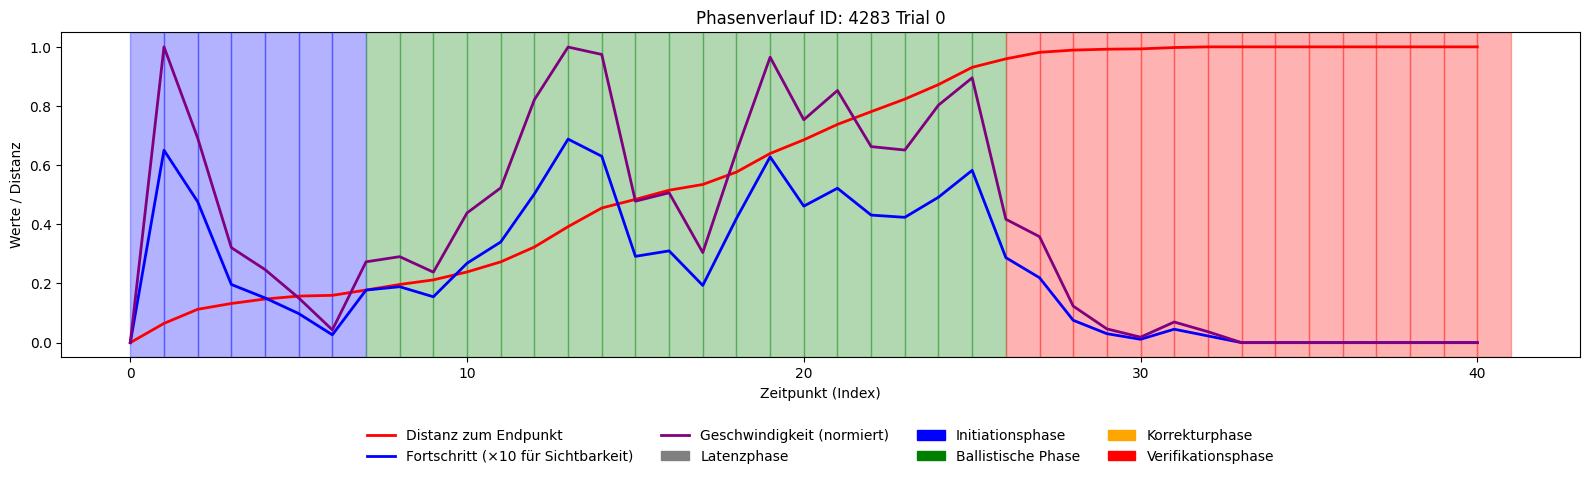

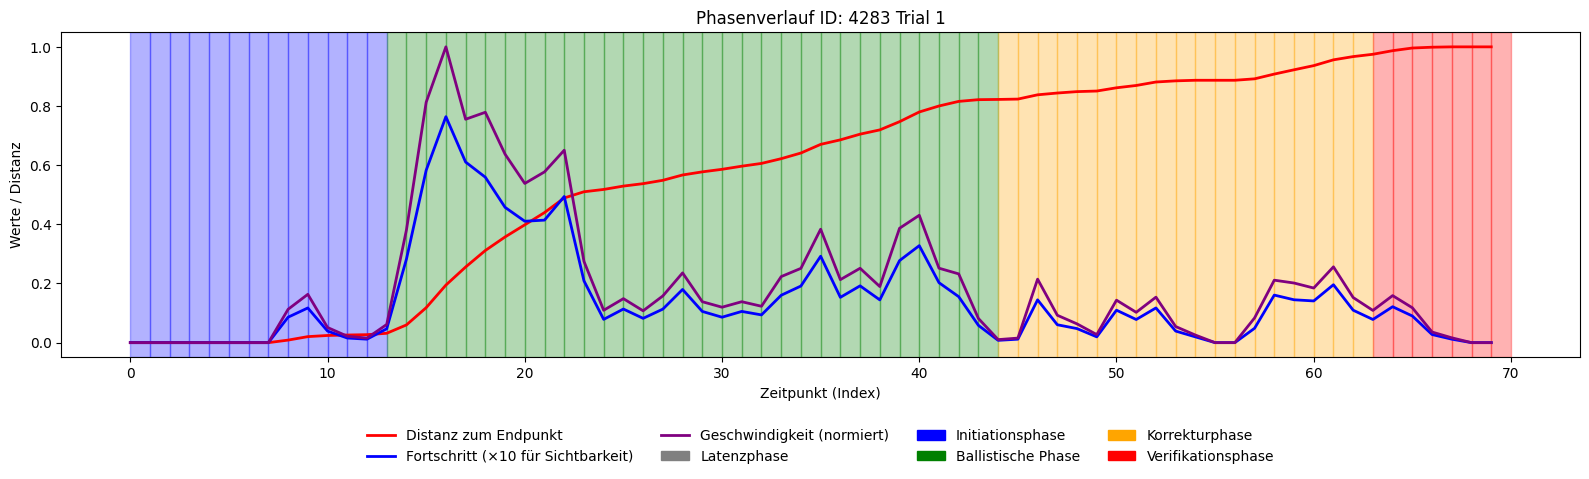

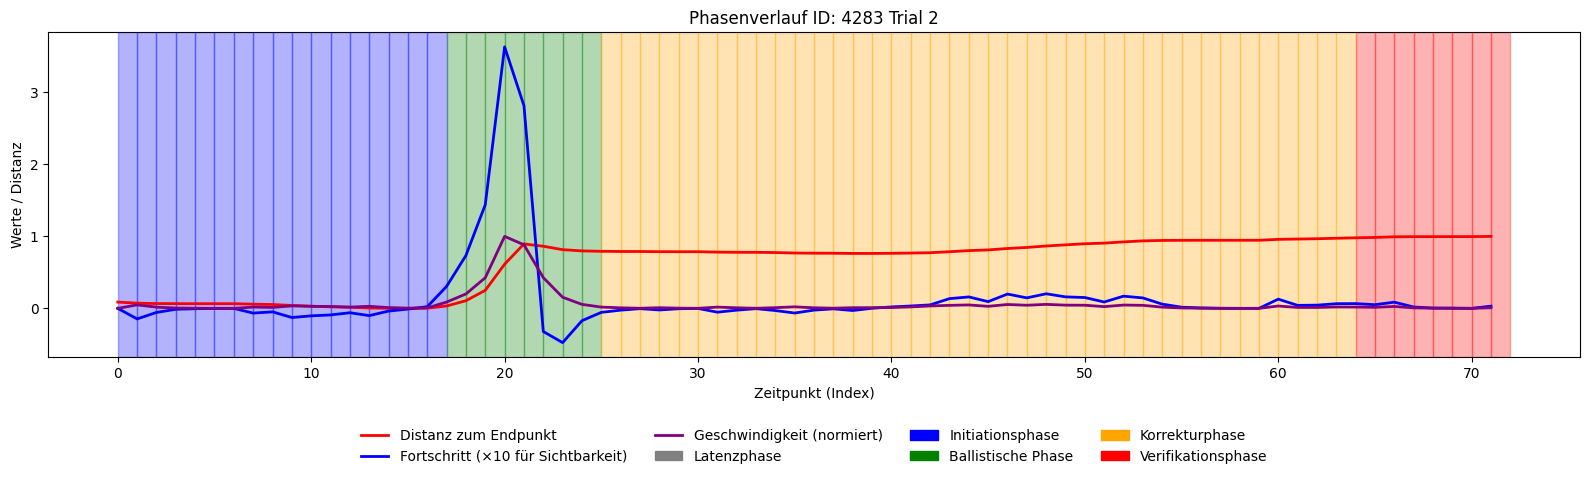

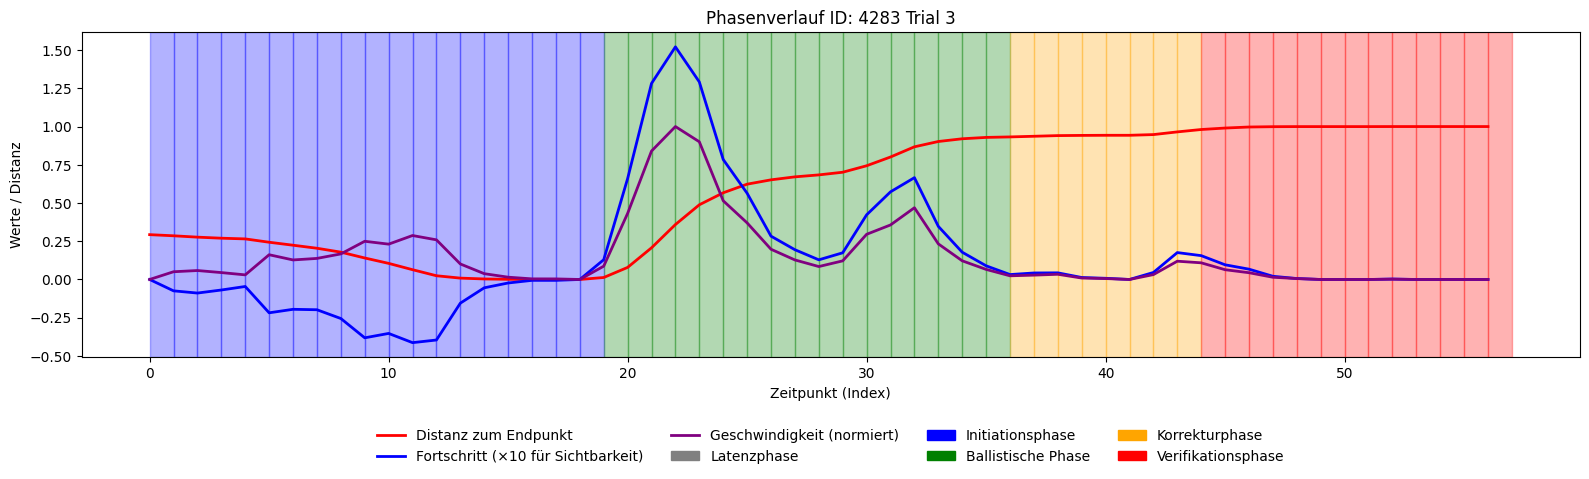

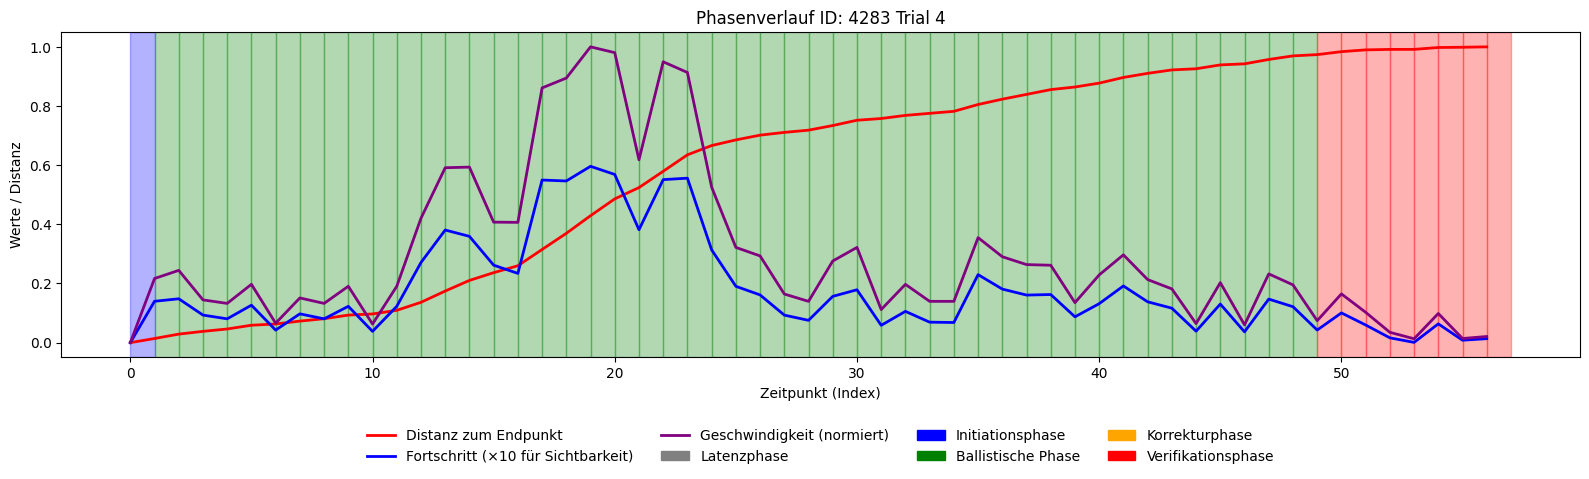

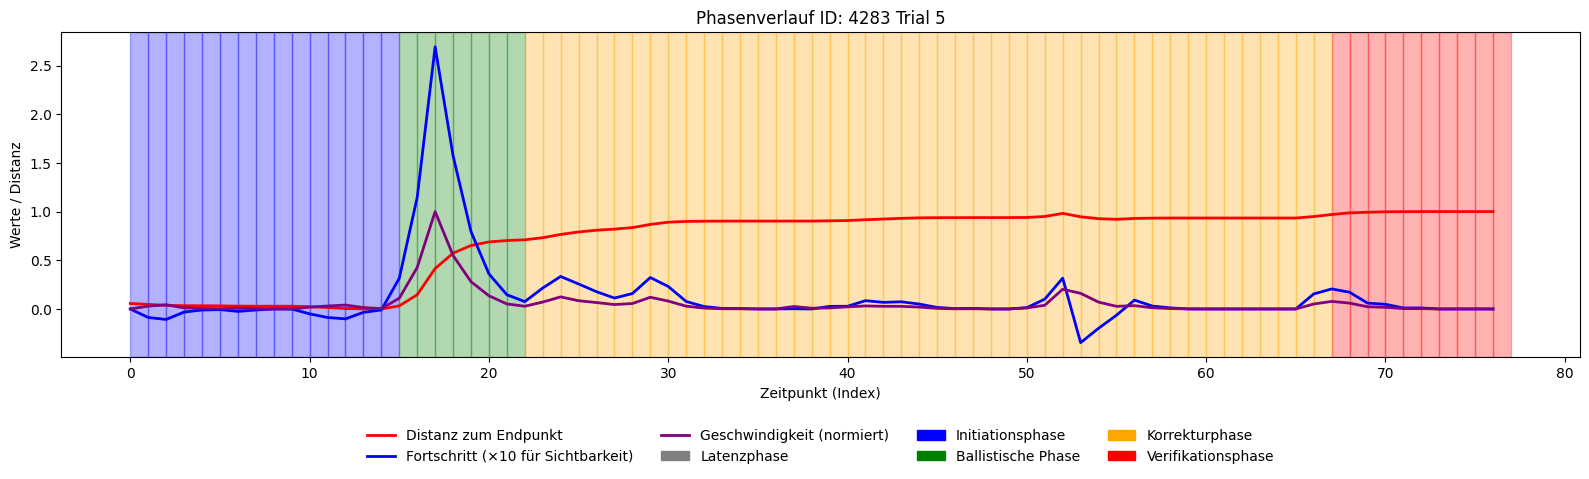

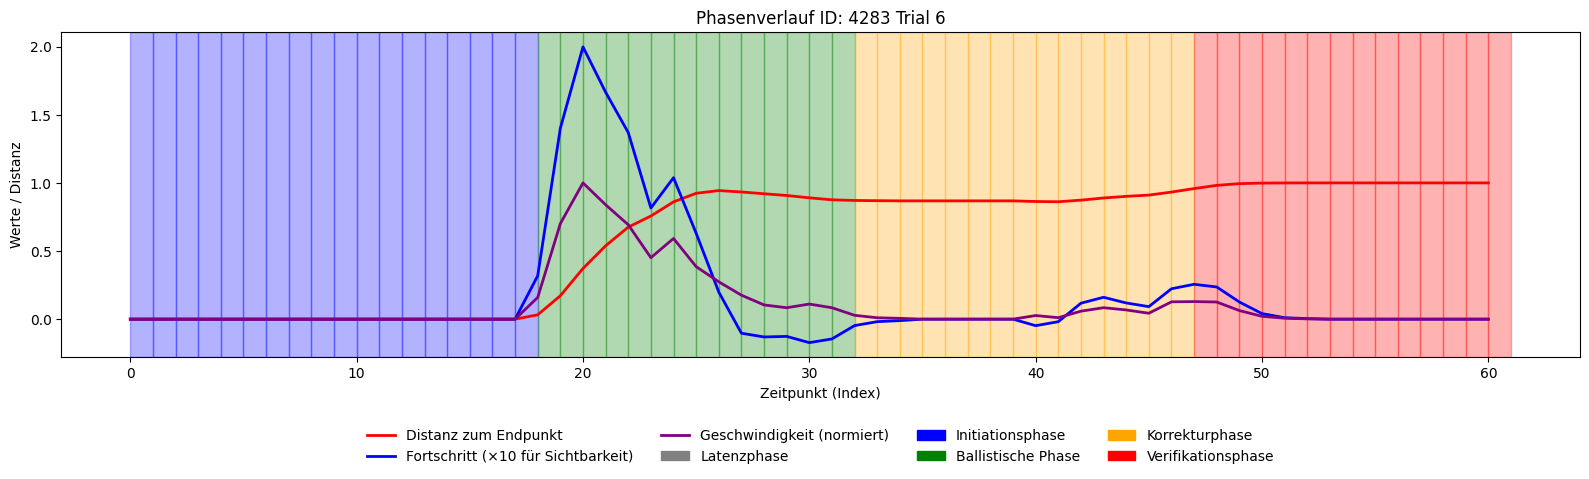

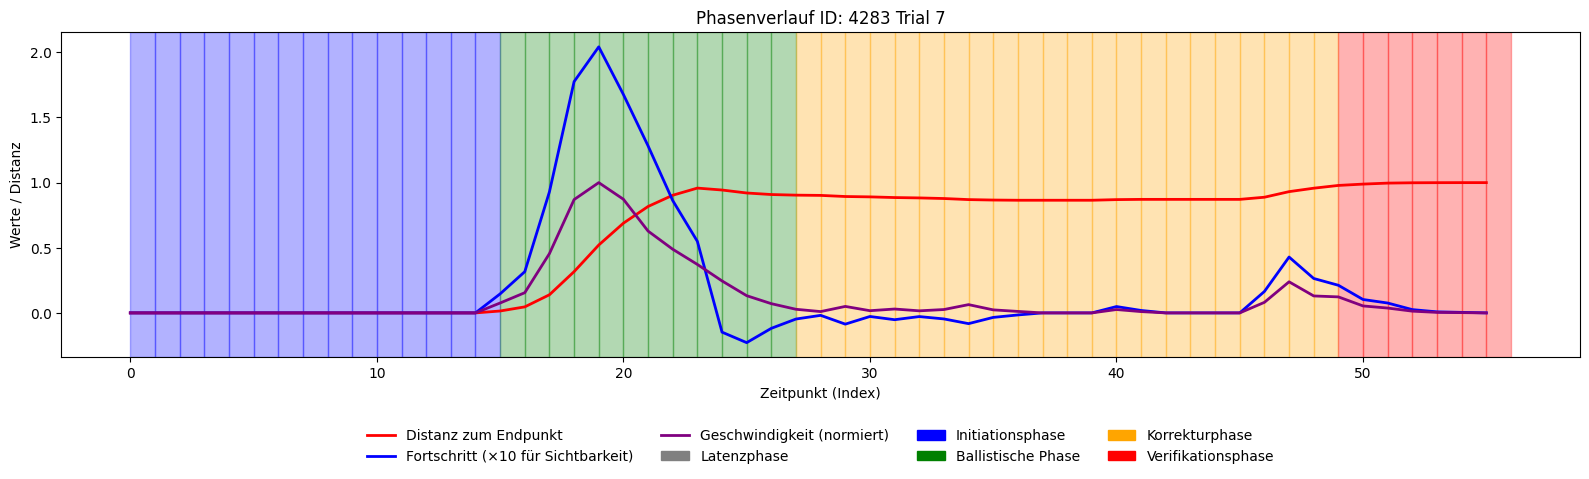

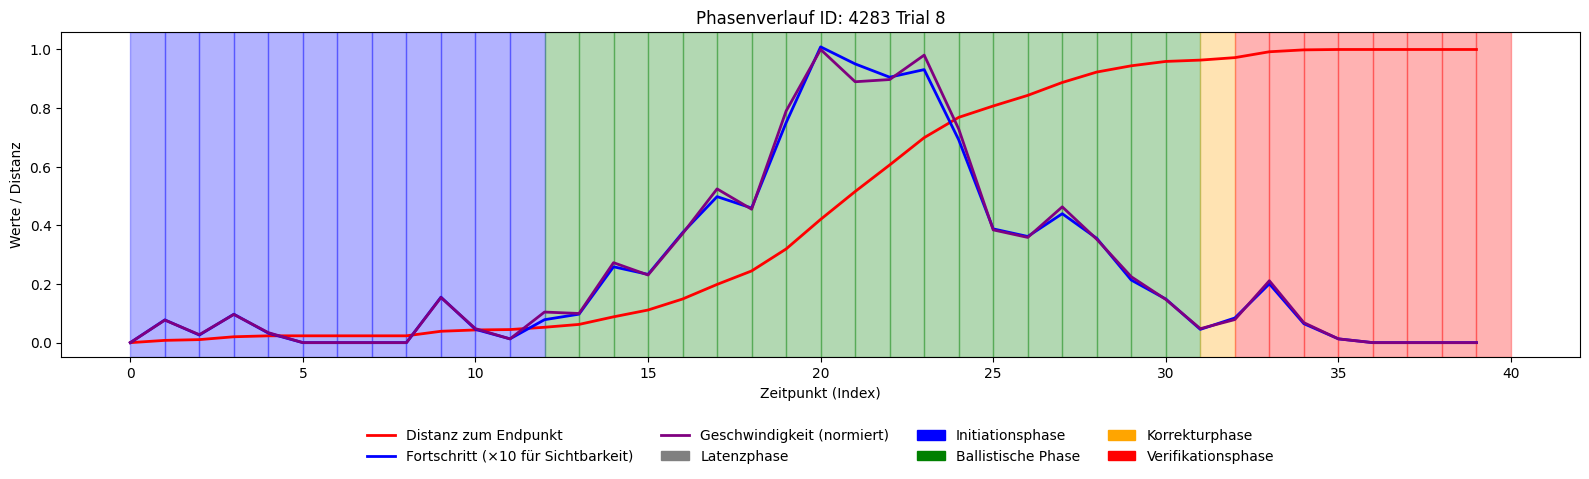

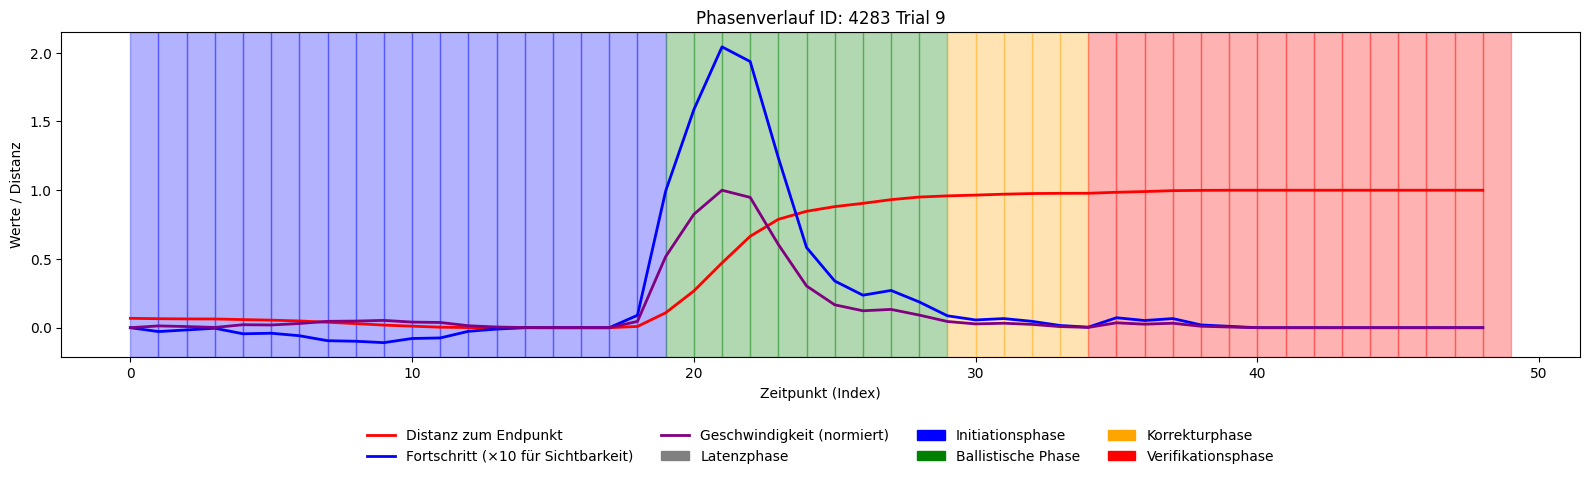

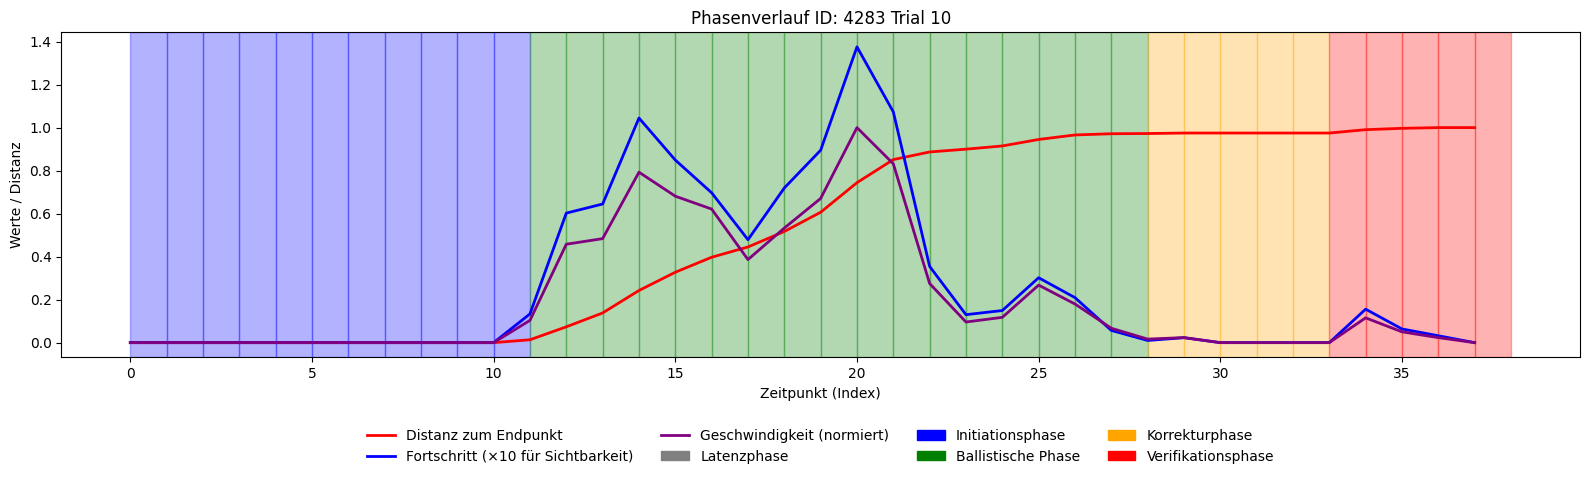

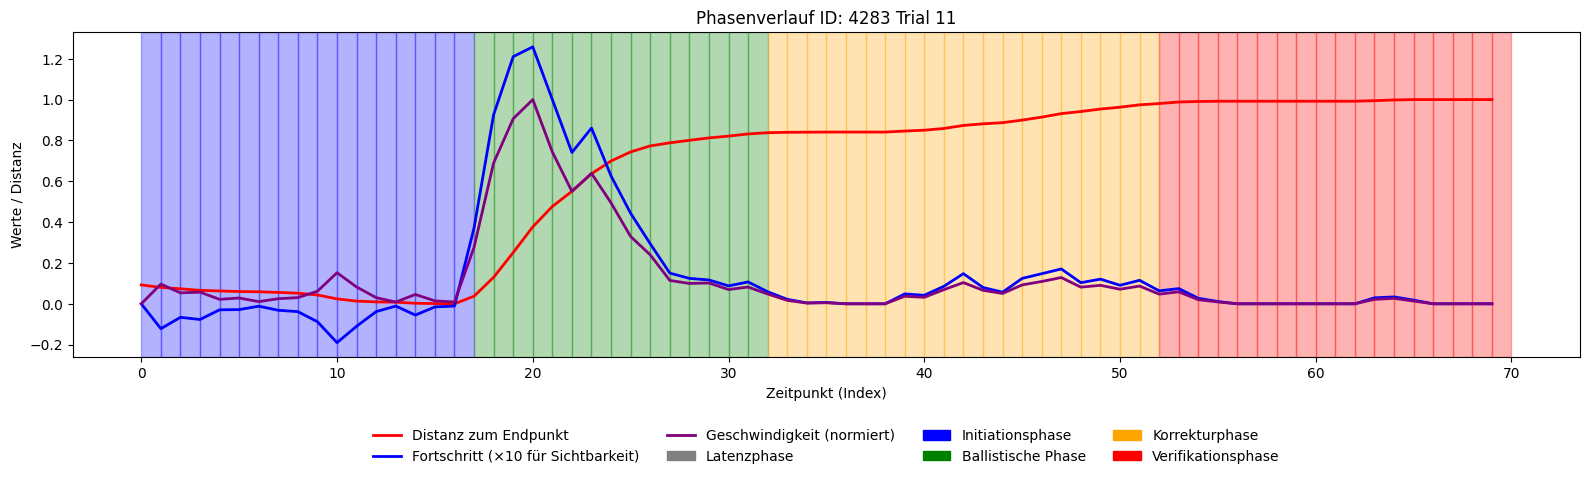

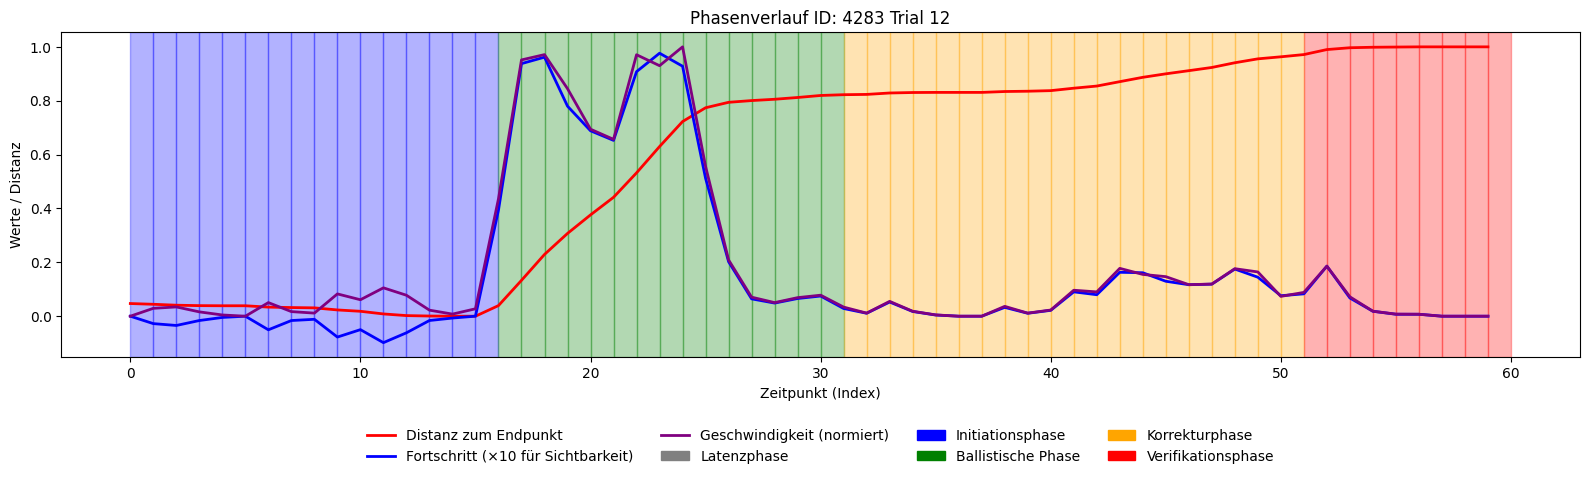

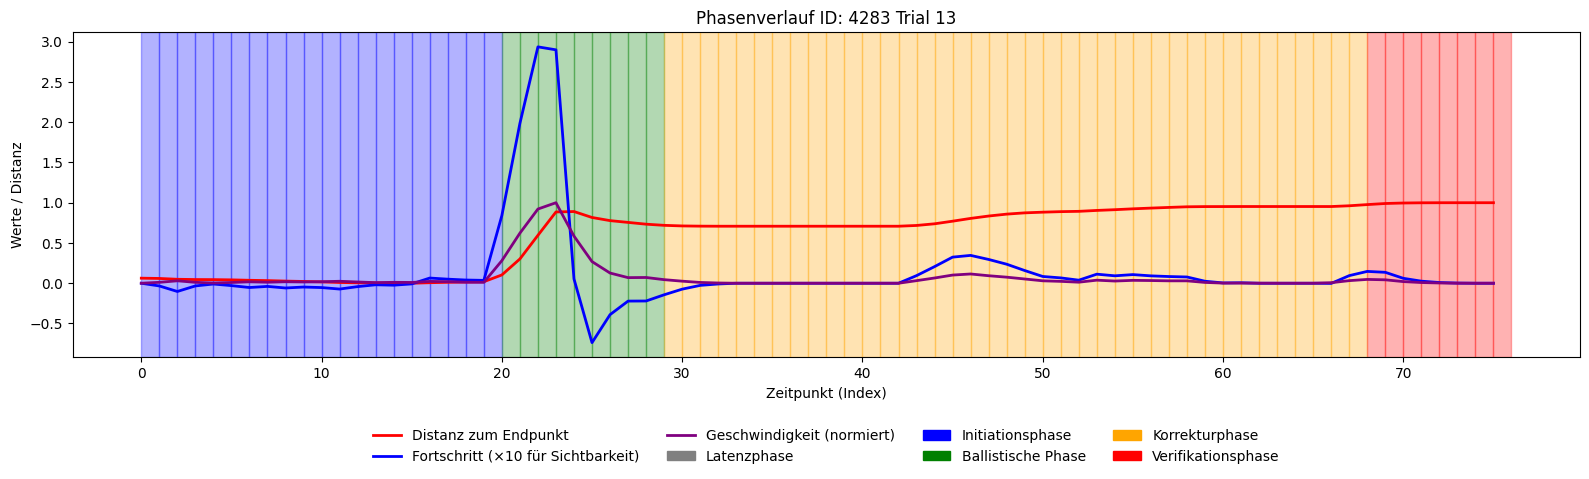

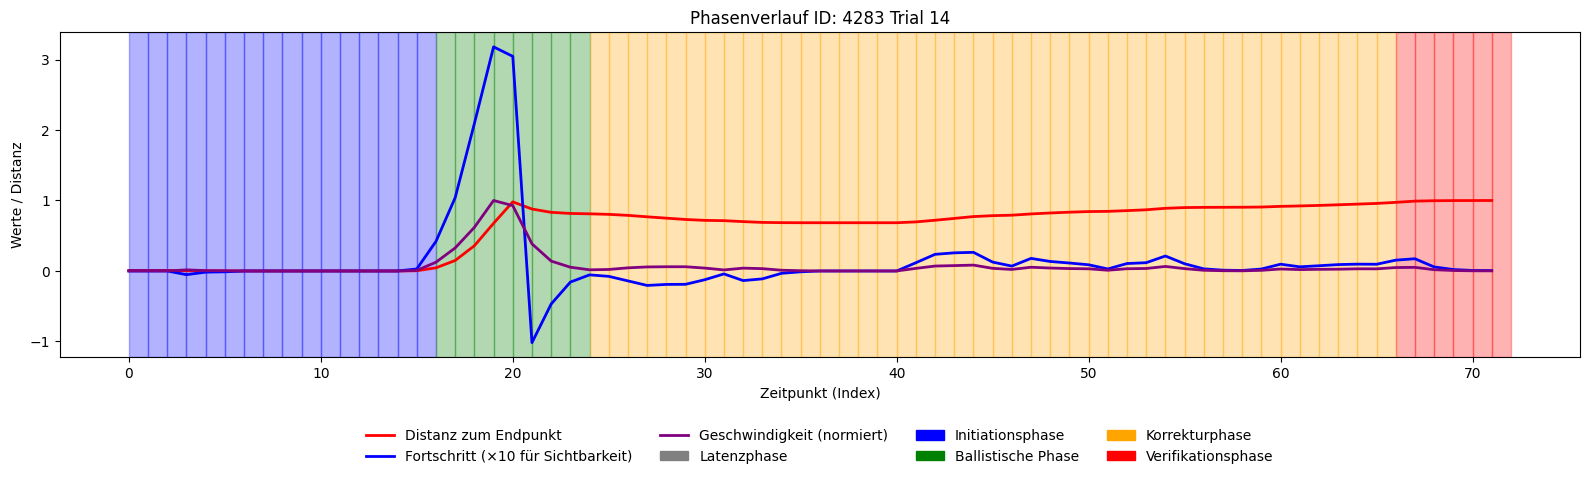

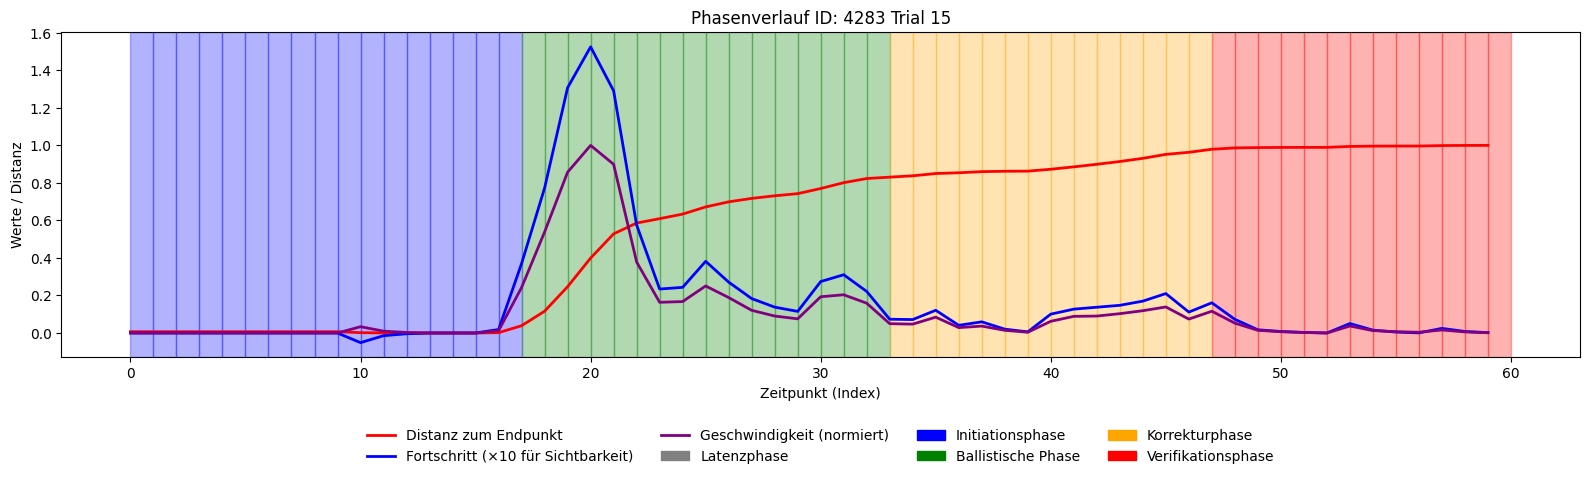

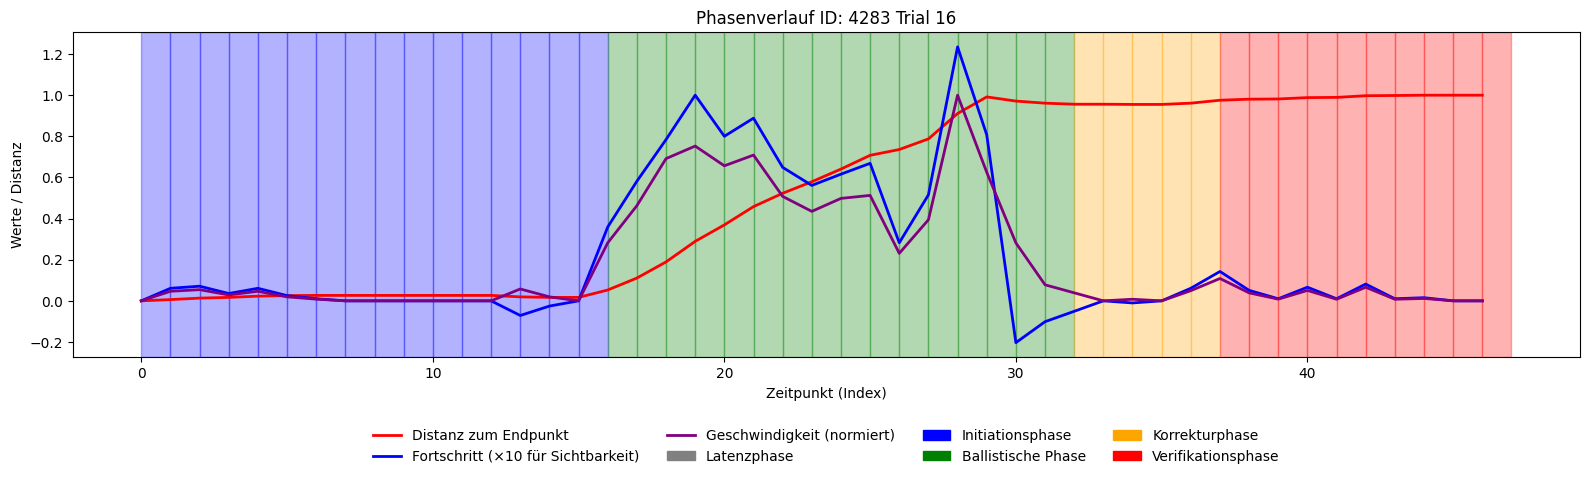

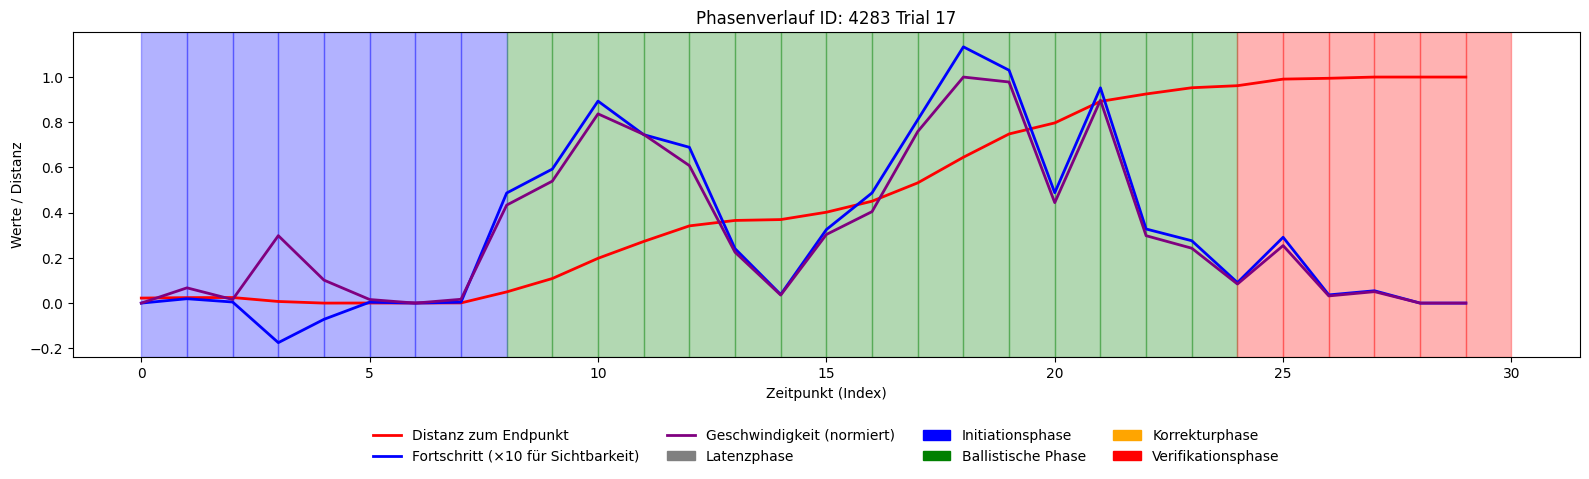

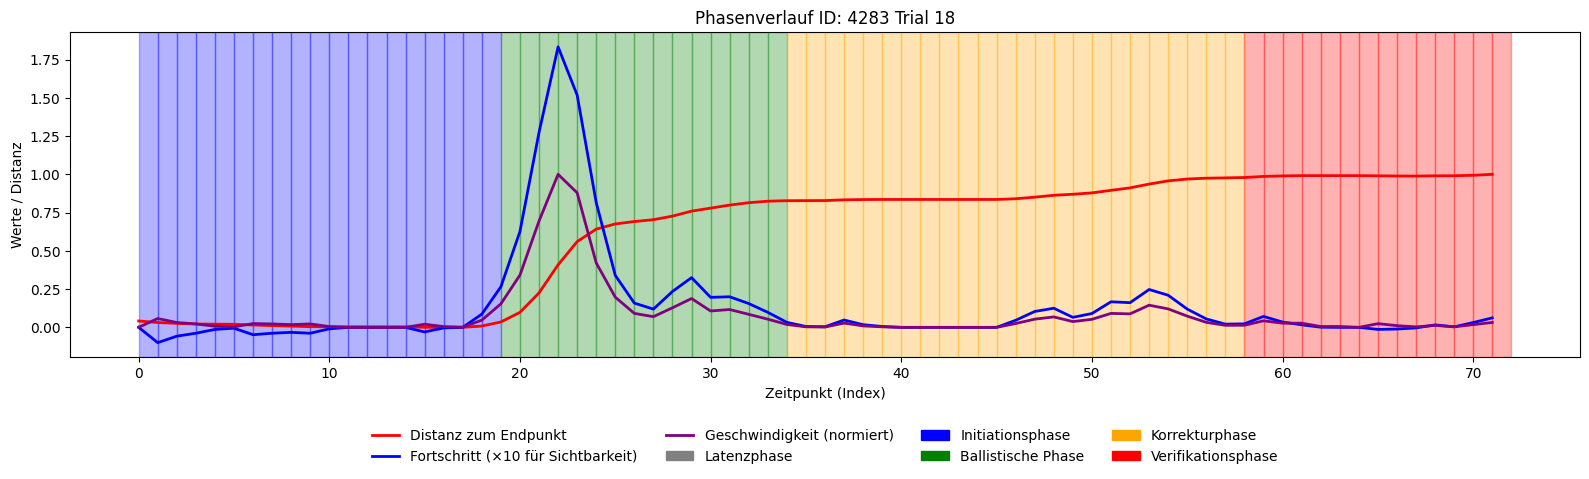

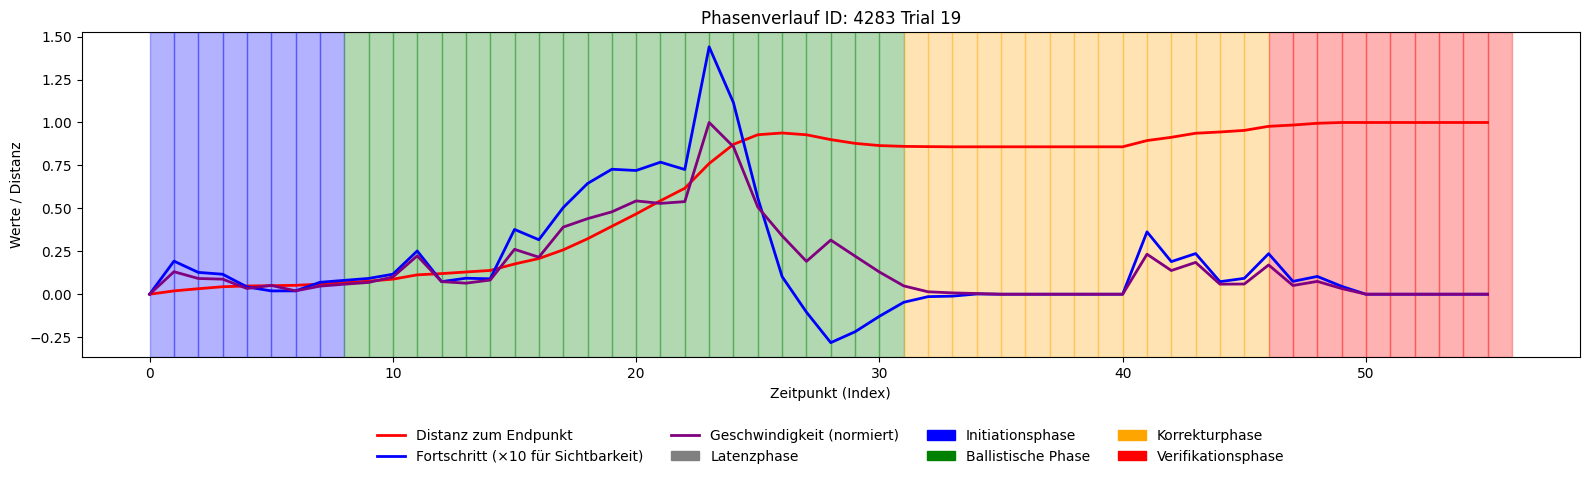

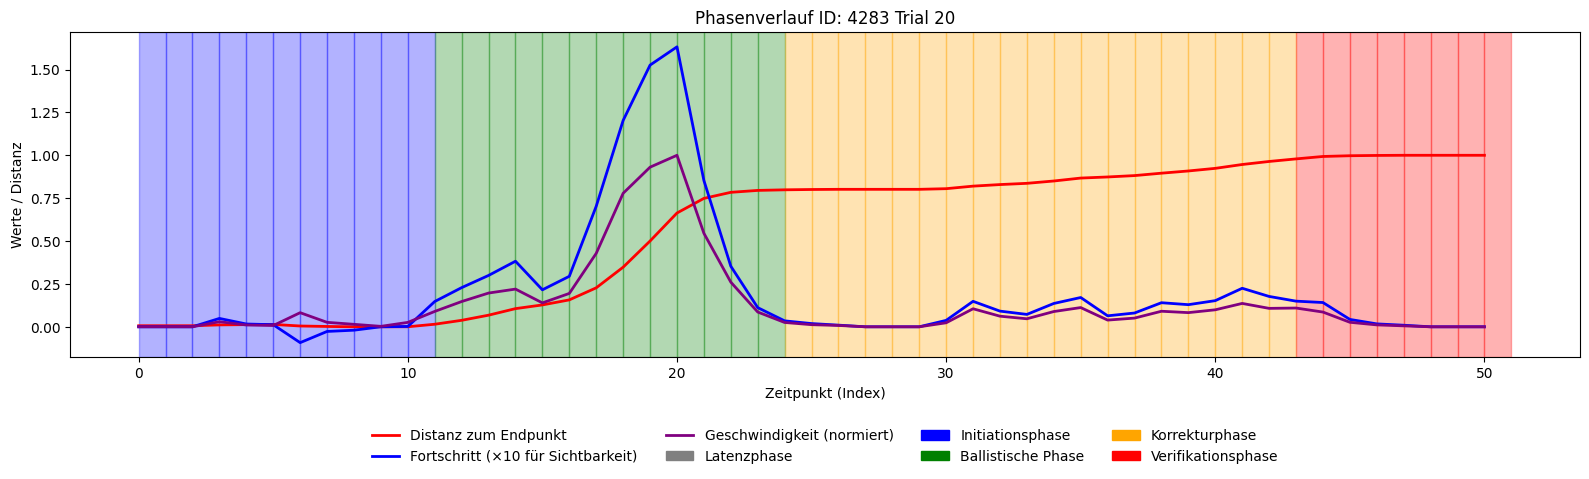

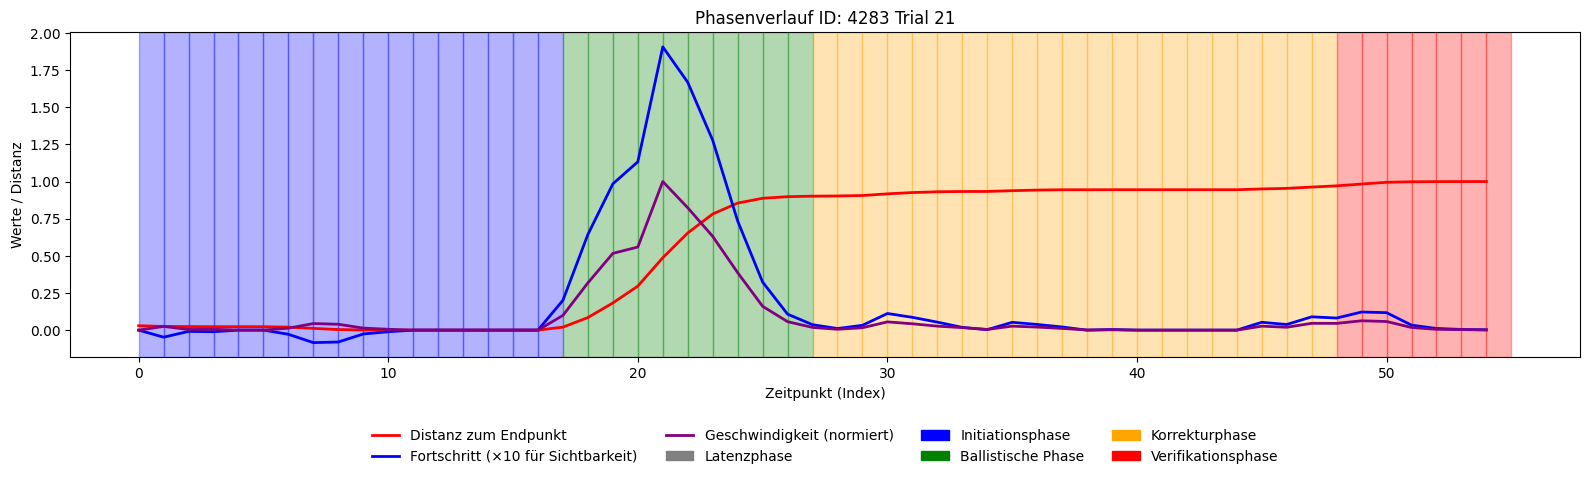

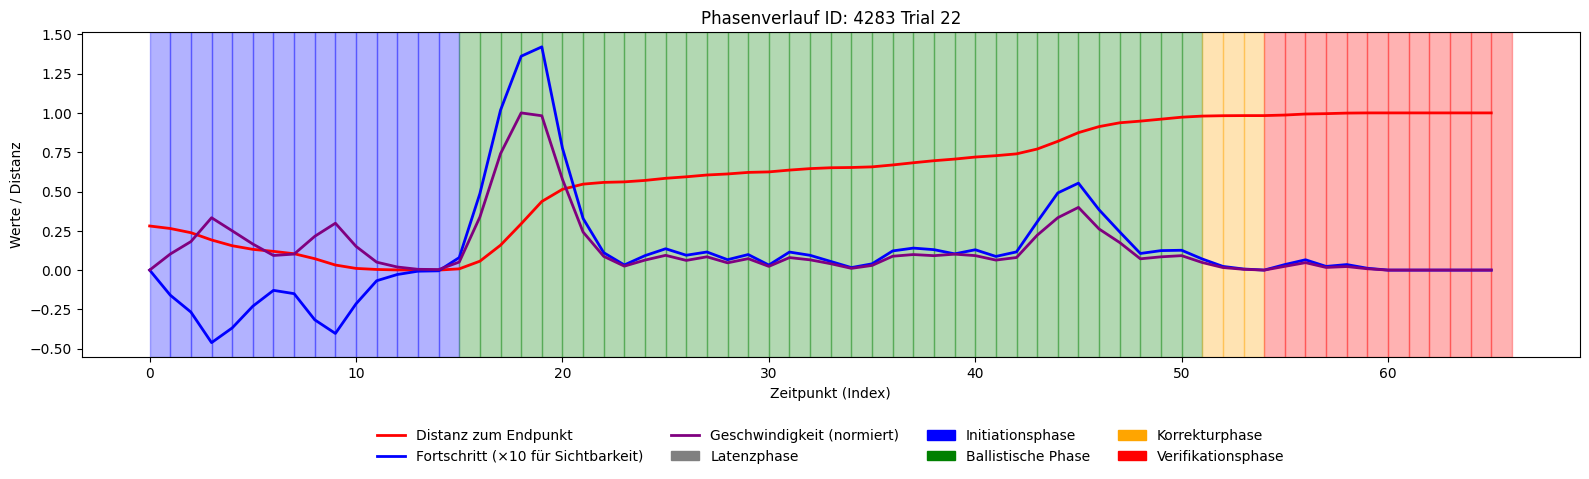

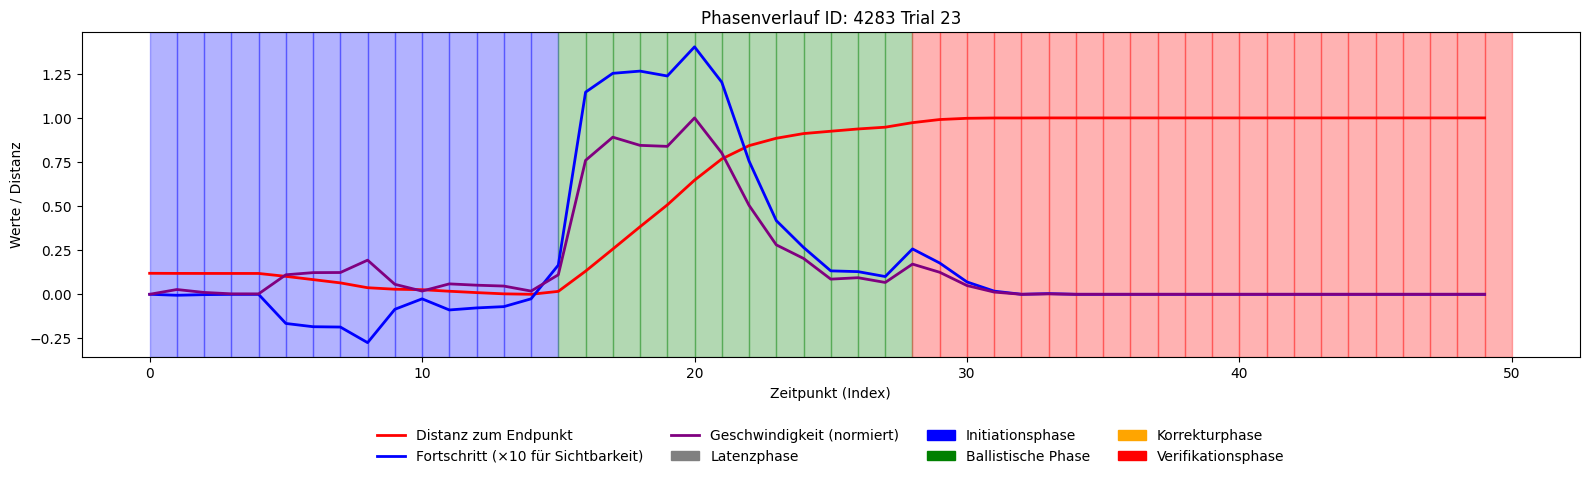

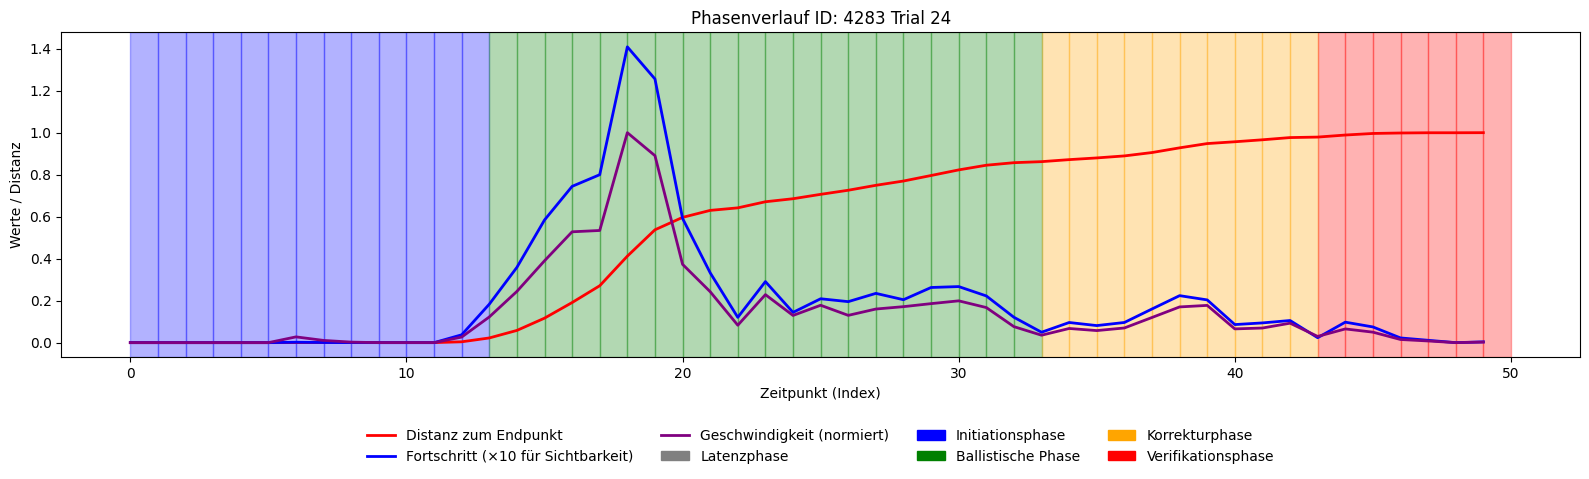

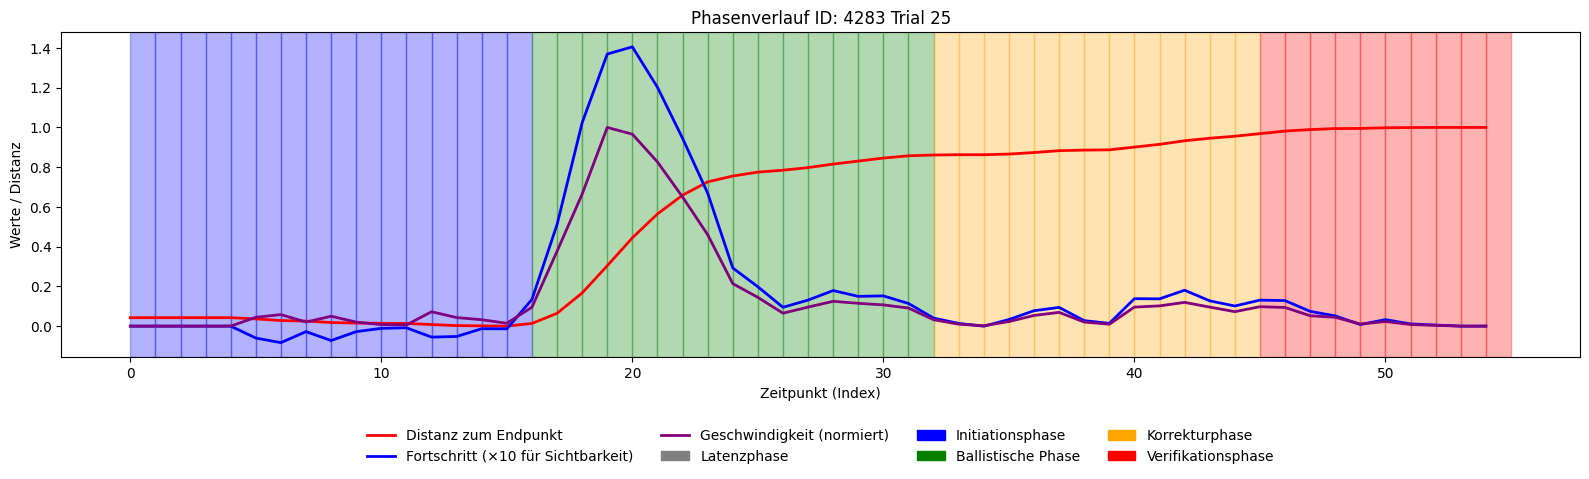

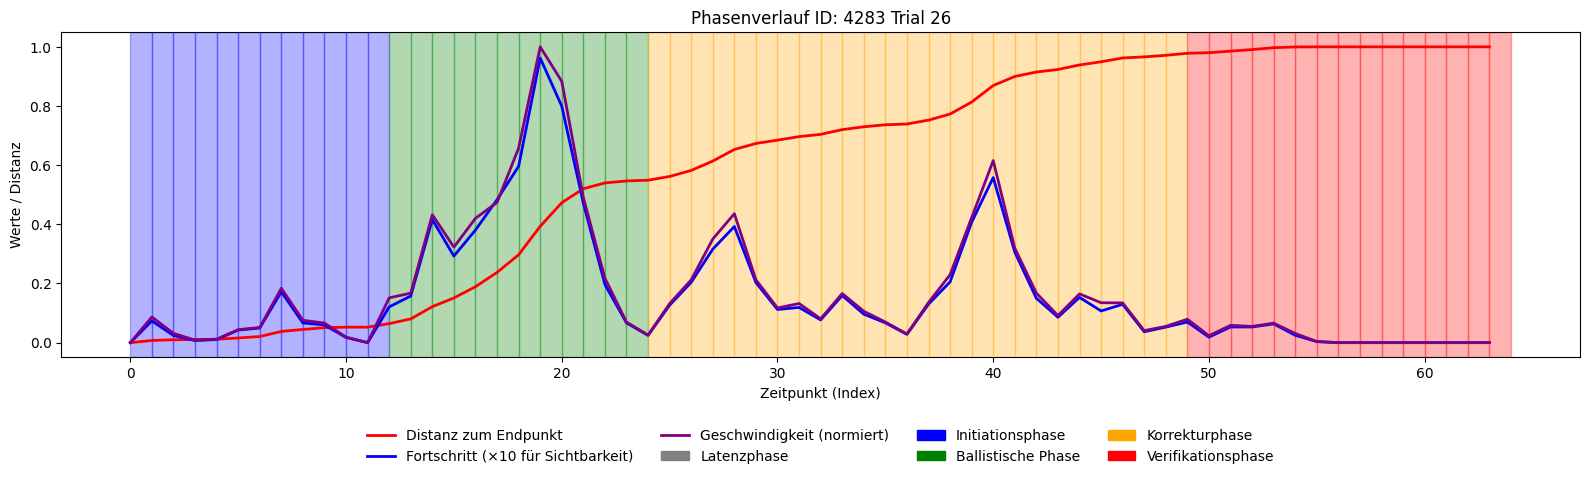

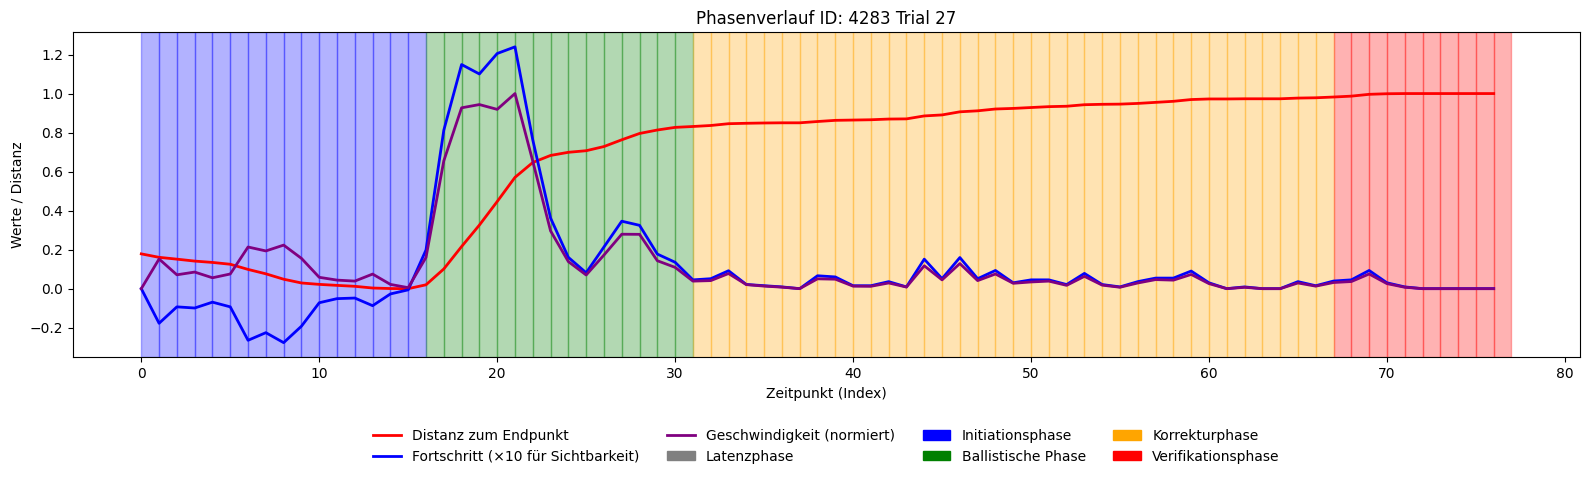

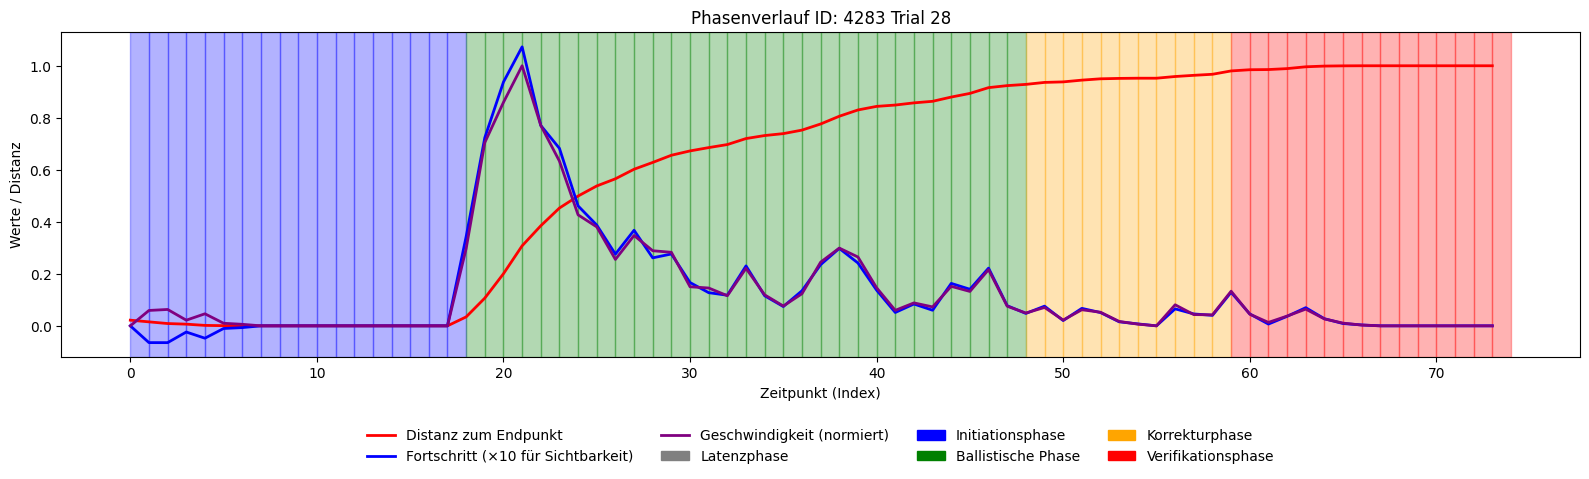

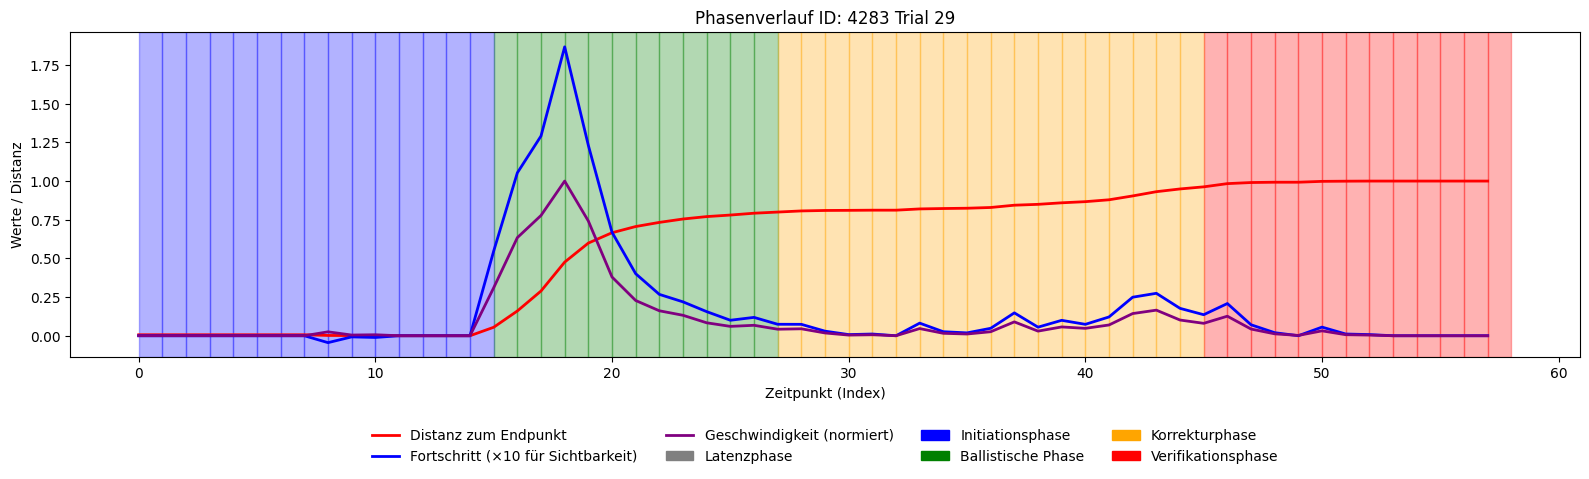

In [ ]:
for i in range(30):
    plot_phases(groups_dict["delay_3_4"][30].iloc[i], index=1)

## Jetzt werden der Initiationszeitpunkt und die Durchschnittsgeschwindigkeit der Ballistischen Phase extrahiert

In [38]:
def calc_ballistic_metrics(row):
    phases = row['phases']
    elapsed = row['elapsed_time_ms']
    speed_per_point = row['speed_per_point']

    res = {
        'time_to_ballistic_start': None,
        'avg_ballistic_speed': None,
        'max_ballistic_speed': None,
        'verification_duration': 0.0,
        'correction_duration': 0.0,
        'ballistic_duration': 0.0
    }

    ballistic_indices = [i for i, p in enumerate(phases) if p == 'Ballistische Phase']
    if ballistic_indices:
        res['time_to_ballistic_start'] = elapsed[ballistic_indices[0]]
        res['ballistic_duration'] = elapsed[ballistic_indices[-1]] - elapsed[ballistic_indices[0]]
        
        speeds = [speed_per_point[i] for i in ballistic_indices]
        if speeds:
            res['avg_ballistic_speed'] = sum(speeds) / len(speeds)
            res['max_ballistic_speed'] = float(np.max(speeds))

    ver_indices = [i for i, p in enumerate(phases) if p == 'Verifikationsphase']
    if ver_indices:
        res['verification_duration'] = elapsed[ver_indices[-1]] - elapsed[ver_indices[0]]

    corr_indices = [i for i, p in enumerate(phases) if p == 'Korrekturphase']
    if corr_indices:
        res['correction_duration'] = elapsed[corr_indices[-1]] - elapsed[corr_indices[0]]

    return pd.Series(res)

In [ ]:
def count_overshoot_undershoot(row):
    progress = row['progress_to_target']
    phases = row['phases'] 

    if not progress or len(progress) < 2:
        return pd.Series({'overshoots': 0, 'undershoots': 0})
    
    correction_indices = [i for i, phase in enumerate(phases) if phase == 'Korrekturphase']
    if not correction_indices:
        return pd.Series({'overshoots': 0, 'undershoots': 0})

    progress = [progress[i] for i in correction_indices]

    if len(progress) < 2:
        return pd.Series({'overshoots': 0, 'undershoots': 0})

    overshoots = 0
    undershoots = 0

    signs = np.sign(progress)

    for i in range(1, len(signs)):
        if signs[i] == 0:
            signs[i] = signs[i-1]

    for prev, curr in zip(signs[:-1], signs[1:]):
        if prev == 1 and curr == -1:
            overshoots += 1
        elif prev == -1 and curr == 1:
            undershoots += 1

    return pd.Series({'overshoots': overshoots, 'undershoots': undershoots})


In [ ]:
import numpy as np

def calculate_auc(row):
    x = np.array(row['mouse_x'])
    y = np.array(row['mouse_y'])
    
    if len(x) < 2:
        return 0.0
    
    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])
    
    points = np.vstack((x, y)).T - p1
    p2_rel = p2 - p1
    
    angle = -np.arctan2(p2_rel[1], p2_rel[0])
    c, s = np.cos(angle), np.sin(angle)
    R = np.array(((c, -s), (s, c)))
    
    points_rot = points @ R.T
    
    y_vals = np.abs(points_rot[:, 1])
    x_vals = points_rot[:, 0]
    area = np.trapezoid(y_vals, x=x_vals)

    
    return area

In [41]:
for group_name, df_list in groups_dict.items():
    for i, df in enumerate(df_list):
        try:
            metrics = df.apply(calc_ballistic_metrics, axis=1)
            df['time_to_ballistic_start'] = metrics['time_to_ballistic_start']
            df['avg_ballistic_speed'] = metrics['avg_ballistic_speed']
            df['max_ballistic_speed'] = metrics['max_ballistic_speed']
            df['verification_duration'] = metrics['verification_duration']
            df['correction_duration'] = metrics['correction_duration']
            df['ballistic_duration'] = metrics['ballistic_duration']
            counts = df.apply(count_overshoot_undershoot, axis=1)
            df['overshoots'] = counts['overshoots']
            df['undershoots'] = counts['undershoots']
            df['auc'] = df.apply(calculate_auc, axis=1)
        except Exception as e:
            print(f"Fehler bei {group_name}[{i}]: {e}")
            continue

In [42]:
def extract_pair_label(group_name):
    return group_name.split("_")[-2] + "_" + group_name.split("_")[-1]


In [ ]:
all_rows = []

for group_name, df_list in groups_dict.items():
    for df in df_list:
        if "time_to_ballistic_start" not in df:
            continue

        temp_df = df[["id", "round", "trial","time_to_ballistic_start", "avg_ballistic_speed", "overshoots", "undershoots", "max_ballistic_speed", "verification_duration", "correction_duration", "ballistic_duration", "auc"]].copy()
        temp_df["pair"] = extract_pair_label(group_name)
        temp_df["condition"] = "delay" if group_name.startswith("delay") else "no_delay"
        

        all_rows.append(temp_df)

plot_df = pd.concat(all_rows, ignore_index=True)


In [44]:
agg_df = (
    plot_df
    .groupby(["id", "condition", "pair"], as_index=False)
    .agg({
        "time_to_ballistic_start": "mean",
        "avg_ballistic_speed": "mean",
        "overshoots": "mean",
        "undershoots": "mean",
        "max_ballistic_speed": "mean",
        "verification_duration": "mean",
        "correction_duration": "mean",
        "ballistic_duration": "mean",
        "auc": "mean"
    })
)


In [52]:
agg_df.to_csv("agg_df.csv", index=False, encoding="utf-8")